# Output layers and cross-entropy

A neural network does not directly output a class name. Its last layer produces numbers, and a loss function teaches us how those numbers should change.

This notebook follows one next-character prediction from the character-level bigram model. We will make every step visible:

1. output neurons produce **logits**;
2. softmax turns logits into a probability distribution;
3. the target identifies one correct class;
4. cross-entropy measures the probability assigned to that class;
5. its gradient tells every output neuron how to move.

The same pattern explains ordinary multiclass classification. At the end, we compare it with binary classification, multilabel prediction, and regression.

## One prediction is one small classification problem

Suppose the current character is `c`. A character-level bigram model must choose the next character from the vocabulary. If the vocabulary is `a, e, i, o, u`, the output layer has five neurons:

\[
\mathbf z = (z_a,z_e,z_i,z_o,z_u).
\]

These are **logits**. They are scores, not probabilities. They may be negative, positive, or larger than one. The output neuron with the largest logit is the model's most favored character, but the logits do not yet tell us how confident the model is or how the scores compare as a distribution.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

sns.set_theme(style="whitegrid", context="notebook")
torch.manual_seed(7)

vocabulary = ["a", "e", "i", "o", "u"]
target_index = vocabulary.index("u")
logits = torch.tensor([1.2, 0.4, -0.1, 0.8, 2.0], dtype=torch.float32)

print("vocabulary:", vocabulary)
print("logits:", logits.tolist())
print("target character:", vocabulary[target_index])

vocabulary: ['a', 'e', 'i', 'o', 'u']
logits: [1.2000000476837158, 0.4000000059604645, -0.10000000149011612, 0.800000011920929, 2.0]
target character: u


## Softmax creates the output distribution

Softmax exponentiates each logit and normalizes the results:

\[
 p_i = \operatorname{softmax}(\mathbf z)_i
     = \frac{e^{z_i}}{\sum_j e^{z_j}}.
\]

Exponentiation makes larger scores matter more, and division makes the values sum to one. The model can now say, for this context, how much probability it assigns to every possible next character.

Softmax does not decide the target and does not compute the loss. It only converts relative scores into probabilities. In PyTorch, `CrossEntropyLoss` combines the numerically stable `log_softmax` operation with negative log-likelihood, so we normally pass it the raw logits.

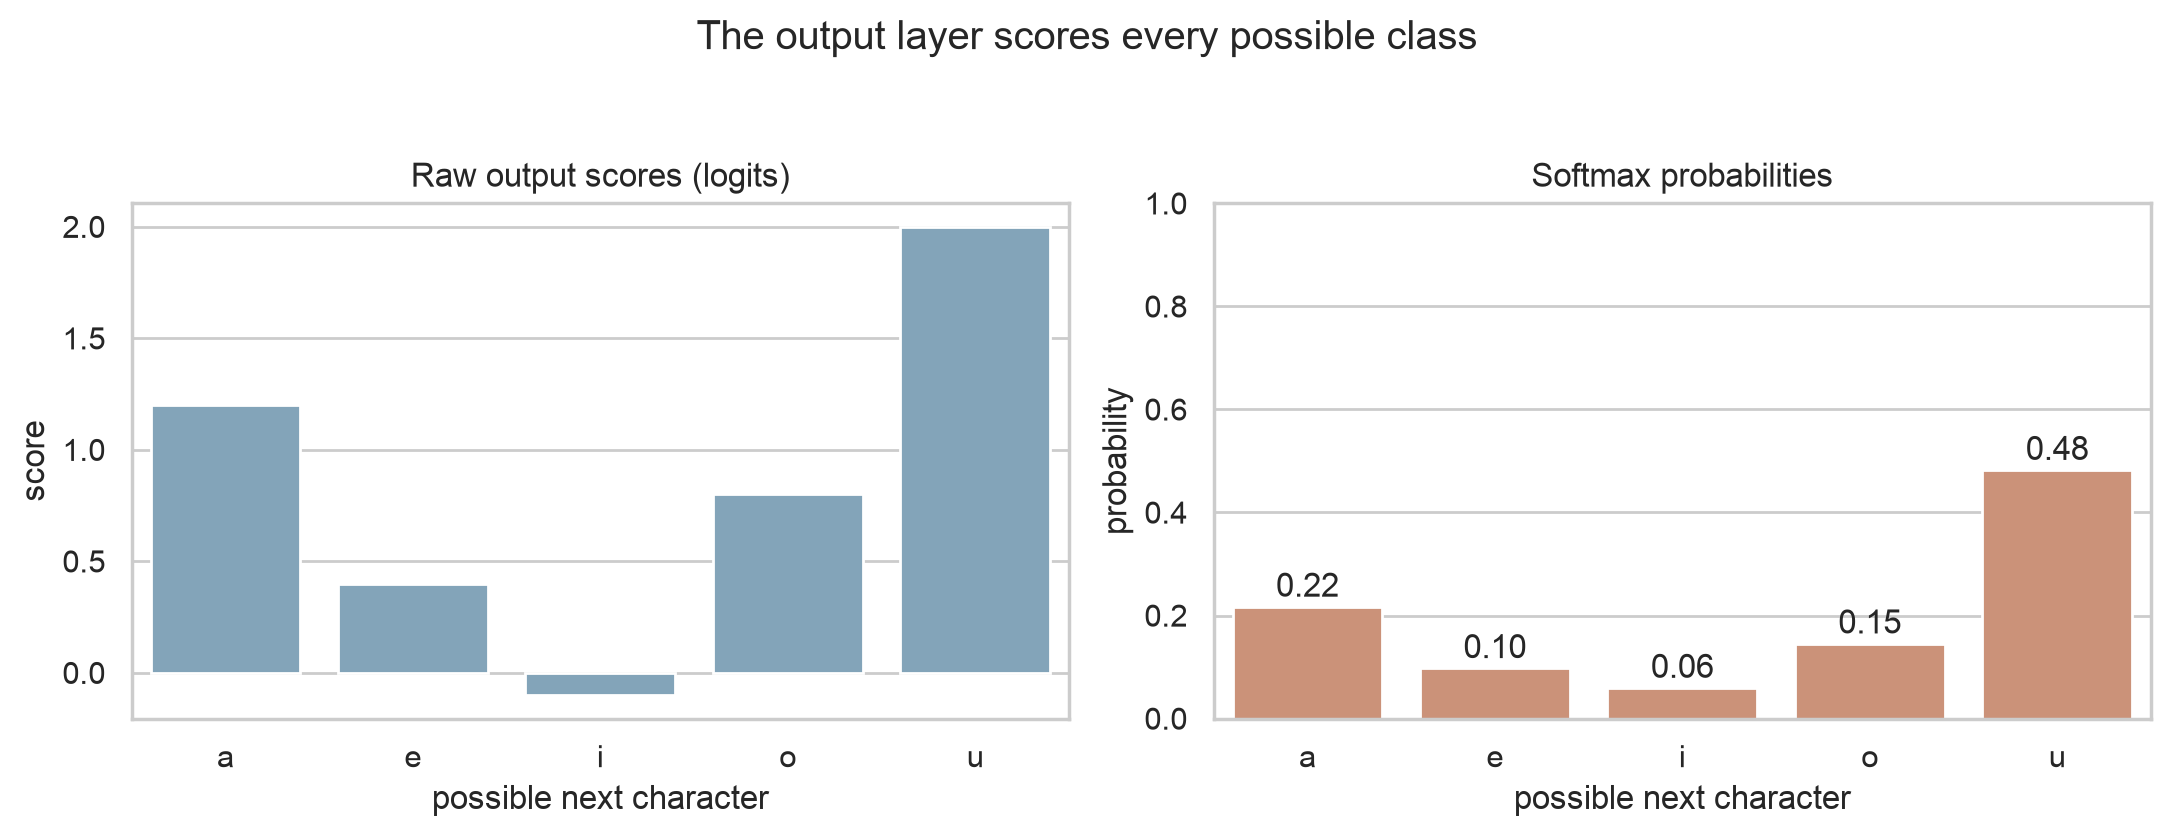

probabilities sum to: 0.9999999403953552


In [2]:
probabilities = torch.softmax(logits, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=vocabulary, y=logits.detach().numpy(), ax=axes[0], color="#7aa6c2")
axes[0].set(title="Raw output scores (logits)", xlabel="possible next character", ylabel="score")

bars = sns.barplot(x=vocabulary, y=probabilities.detach().numpy(), ax=axes[1], color="#d98c6b")
axes[1].set(title="Softmax probabilities", xlabel="possible next character", ylabel="probability")
axes[1].set_ylim(0, 1)
for bar, value in zip(bars.patches, probabilities.tolist()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.2f}", ha="center")

fig.suptitle("The output layer scores every possible class", y=1.04)
plt.tight_layout()
plt.show()

print("probabilities sum to:", probabilities.sum().item())

## Cross-entropy asks one specific question

For a single example, the target is the correct class index. Here the target is `u`, so the loss uses only the probability assigned to `u`:

\[
\mathcal L = -\log p_{\text{target}}.
\]

The other probabilities still matter indirectly because they compete for the fixed probability mass, but the loss is not an average of five independent errors. It asks: **how surprised was the model by the correct answer?**

- If the model assigns probability `1.0` to the target, the loss is `0`.
- If it assigns probability `0.5`, the loss is about `0.69`.
- If it assigns probability `0.01`, the loss is about `4.61`.

A wrong, confident prediction is therefore penalized much more than an uncertain one.

target probability: 0.4820
manual cross-entropy: 0.7299
PyTorch CrossEntropyLoss: 0.7299


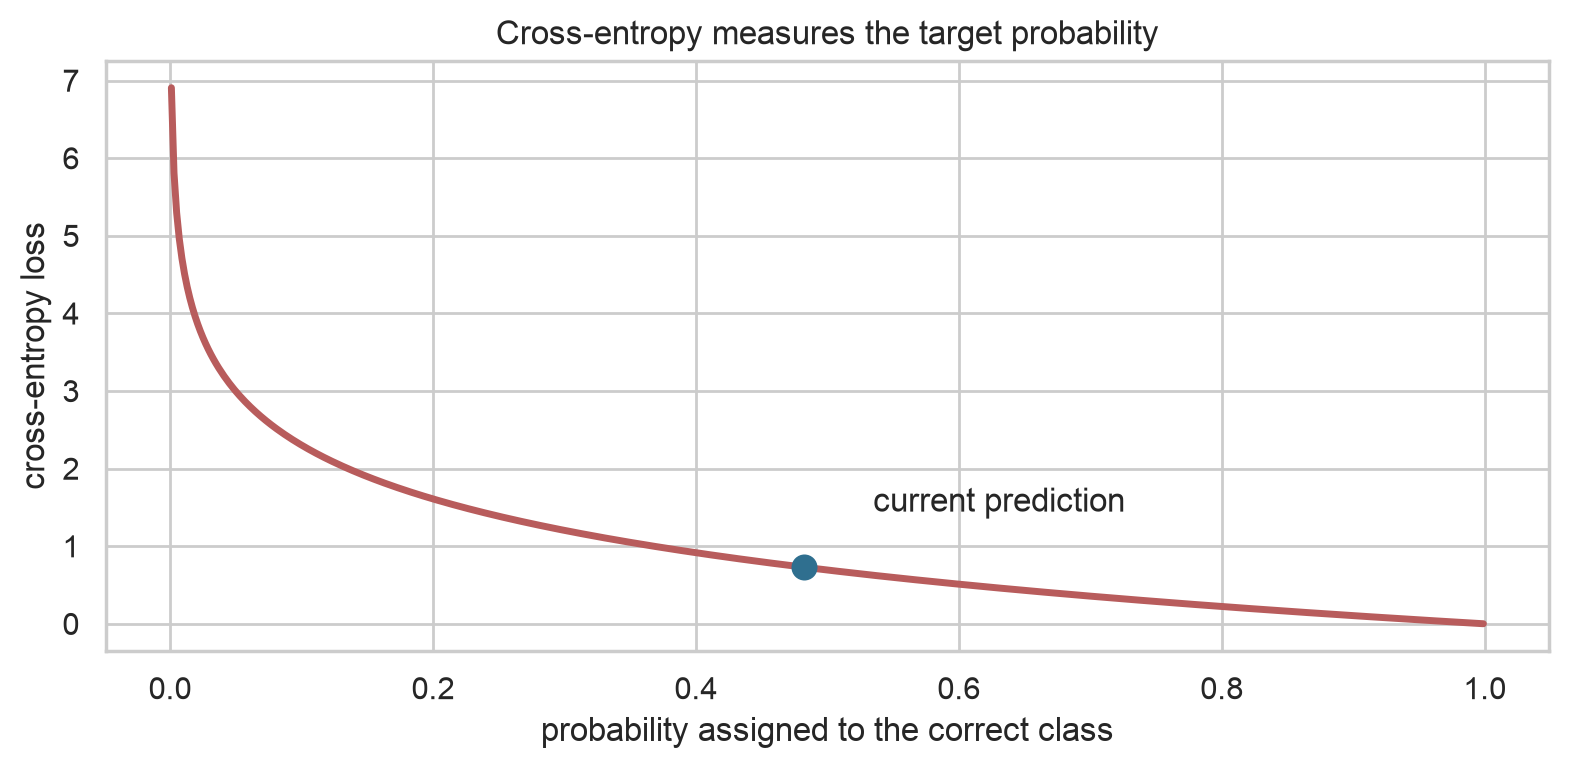

In [3]:
loss = -torch.log(probabilities[target_index])
loss_from_pytorch = nn.CrossEntropyLoss()(logits.unsqueeze(0), torch.tensor([target_index]))

print(f"target probability: {probabilities[target_index].item():.4f}")
print(f"manual cross-entropy: {loss.item():.4f}")
print(f"PyTorch CrossEntropyLoss: {loss_from_pytorch.item():.4f}")

confidence = torch.linspace(0.001, 0.999, 500)
loss_curve = -torch.log(confidence)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(confidence.numpy(), loss_curve.numpy(), color="#b85c5c", linewidth=2.5)
ax.scatter([probabilities[target_index].item()], [loss.item()], color="#2f6f8f", s=70, zorder=3)
ax.annotate("current prediction", (probabilities[target_index].item(), loss.item()), xytext=(25, 20), textcoords="offset points")
ax.set(xlabel="probability assigned to the correct class", ylabel="cross-entropy loss", title="Cross-entropy measures the target probability")
plt.tight_layout()
plt.show()

## Why the output neurons move in different directions

For softmax followed by cross-entropy, the gradient with respect to each logit has a simple form:

\[
\frac{\partial \mathcal L}{\partial z_i} = p_i - y_i,
\]

where `y` is a one-hot target vector. For the correct neuron, `y_i = 1`, so its gradient is `p_i - 1`, which is negative. Gradient descent therefore **raises** its logit. For every incorrect neuron, `y_i = 0`, so its gradient is `p_i`, which is positive. Gradient descent therefore **lowers** those logits.

This is the precise sense in which the loss activates the correct output neuron: it does not switch a neuron on by a rule. It produces a signed update that raises the correct score and suppresses the competing scores.

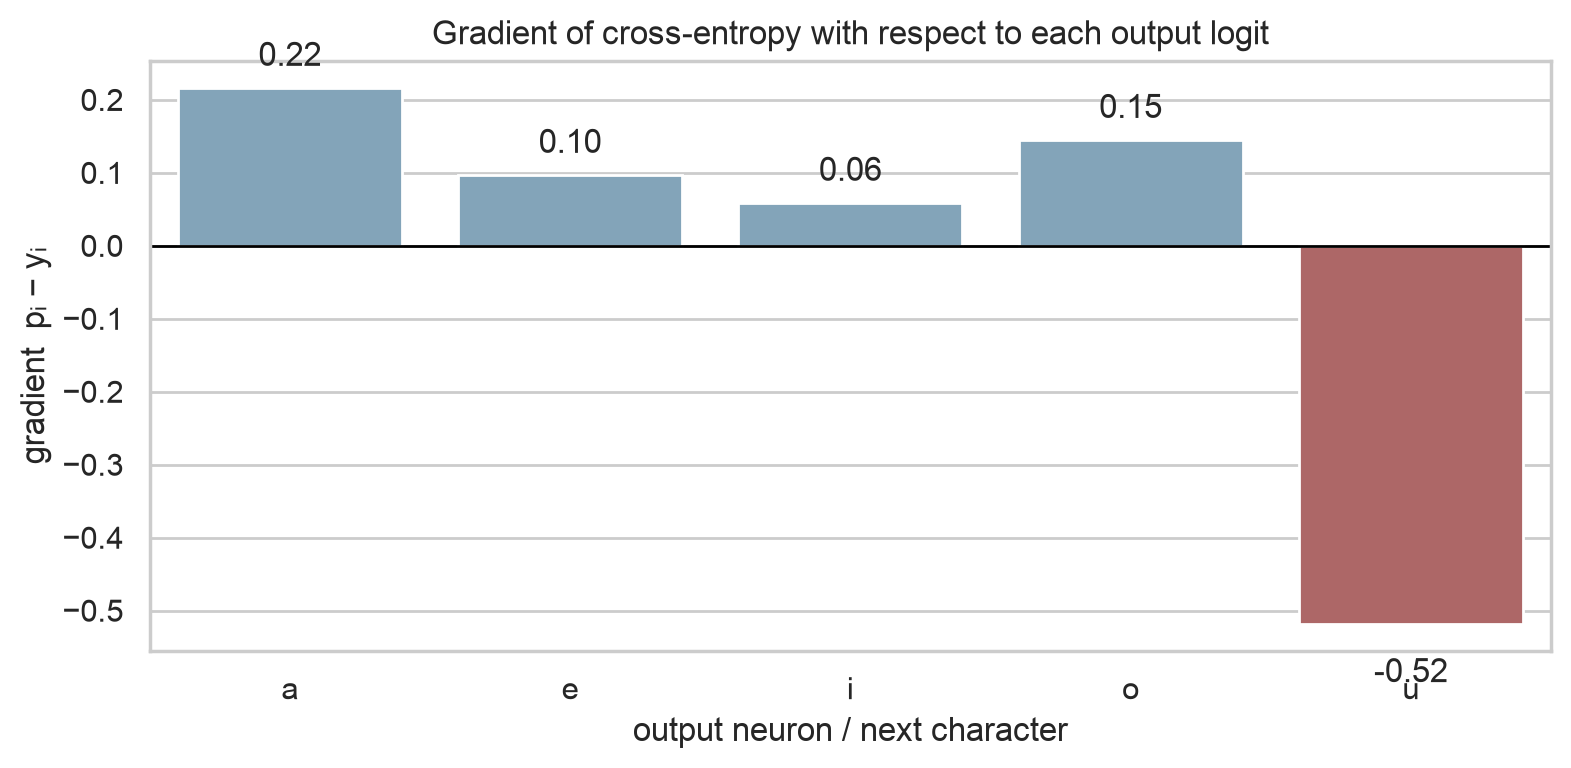

probabilities: [0.21655701100826263, 0.09730532765388489, 0.05901867151260376, 0.14516247808933258, 0.48195645213127136]
one-hot target: [0, 0, 0, 0, 1]
gradient: [0.21655699610710144, 0.0973053127527237, 0.05901866778731346, 0.14516247808933258, -0.518043577671051]


In [4]:
logits_for_gradient = logits.clone().requires_grad_()
loss = nn.CrossEntropyLoss()(logits_for_gradient.unsqueeze(0), torch.tensor([target_index]))
loss.backward()
gradients = logits_for_gradient.grad.detach()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#b85c5c" if i == target_index else "#7aa6c2" for i in range(len(vocabulary))]
sns.barplot(x=vocabulary, y=gradients.numpy(), palette=colors, ax=ax, hue=vocabulary, legend=False)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Gradient of cross-entropy with respect to each output logit", xlabel="output neuron / next character", ylabel="gradient  pᵢ − yᵢ")
for bar, value in zip(ax.patches, gradients.tolist()):
    ax.text(bar.get_x() + bar.get_width() / 2, value + (0.03 if value >= 0 else -0.08), f"{value:.2f}", ha="center")
plt.tight_layout()
plt.show()

print("probabilities:", probabilities.tolist())
print("one-hot target:", torch.nn.functional.one_hot(torch.tensor(target_index), num_classes=len(vocabulary)).tolist())
print("gradient:", gradients.tolist())

## A tiny trainable bigram model

The full character-level bigram model is just a table of logits. Row `c` contains one logit for every possible next character. An embedding layer is a convenient PyTorch representation of that table: looking up the current character returns its row.

Each training pair has:

- an input character ID `x`;
- a target next-character ID `y`;
- one row of output logits `model(x)`;
- one cross-entropy value comparing that row with `y`.

There is no hidden sequence model yet. This is the same conditional-probability idea as the project notebook, expressed as trainable output neurons.

In [5]:
text = "the quick brown fox jumps over the lazy dog. " * 30
vocabulary = sorted(set(text))
to_id = {char: index for index, char in enumerate(vocabulary)}
encoded = torch.tensor([to_id[char] for char in text], dtype=torch.long)
inputs = encoded[:-1]
targets = encoded[1:]

class BigramLogitTable(nn.Module):
    def __init__(self, vocabulary_size):
        super().__init__()
        self.logits = nn.Embedding(vocabulary_size, vocabulary_size)

    def forward(self, input_ids):
        return self.logits(input_ids)

model = BigramLogitTable(len(vocabulary))
optimizer = torch.optim.SGD(model.parameters(), lr=0.8)
loss_function = nn.CrossEntropyLoss()
loss_history = []

for step in range(600):
    logits_batch = model(inputs)
    loss = loss_function(logits_batch, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print(f"vocabulary size: {len(vocabulary)}")
print(f"initial loss: {loss_history[0]:.3f}")
print(f"final loss: {loss_history[-1]:.3f}")

vocabulary size: 28
initial loss: 4.033
final loss: 0.761


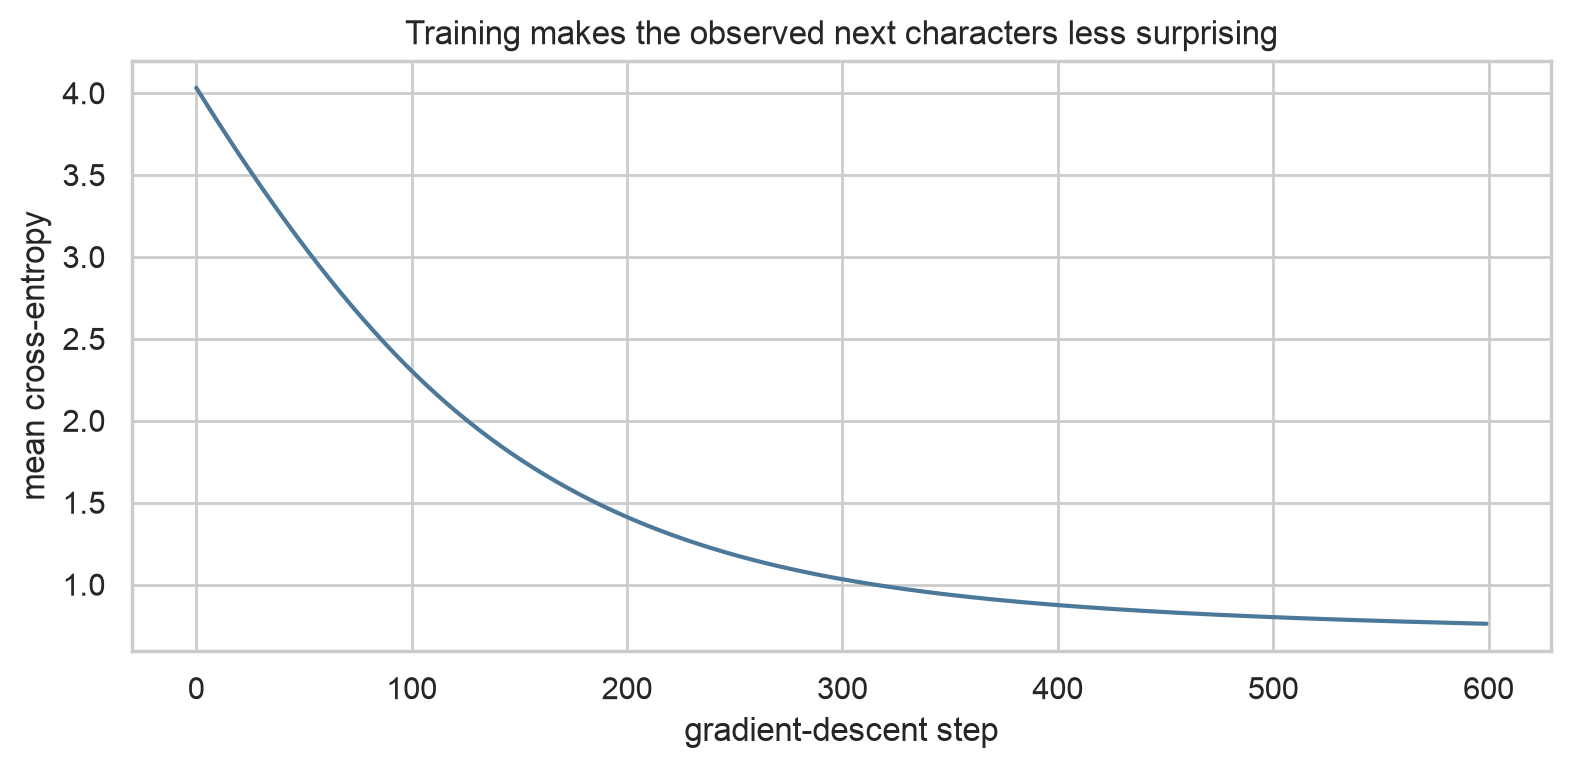

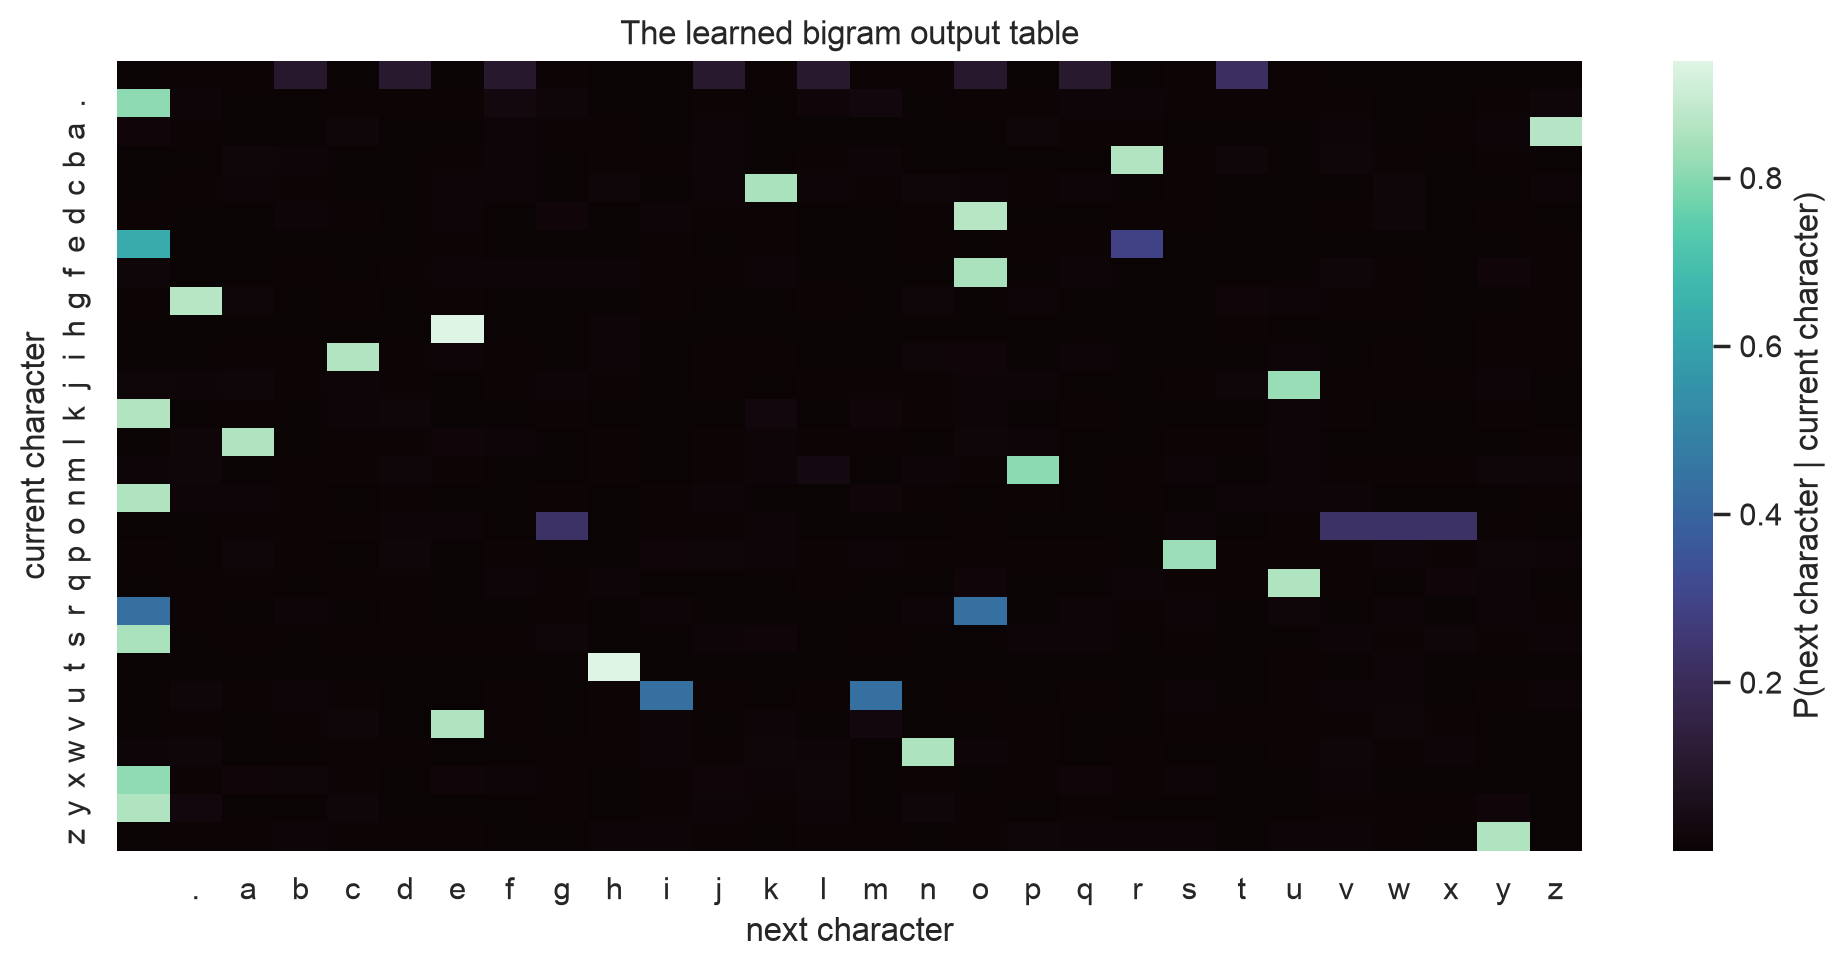

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color="#4c7899")
ax.set(xlabel="gradient-descent step", ylabel="mean cross-entropy", title="Training makes the observed next characters less surprising")
plt.tight_layout()
plt.show()

with torch.no_grad():
    learned_probabilities = torch.softmax(model.logits.weight, dim=1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(learned_probabilities.numpy(), cmap="mako", xticklabels=vocabulary, yticklabels=vocabulary, ax=ax, cbar_kws={"label": "P(next character | current character)"})
ax.set(xlabel="next character", ylabel="current character", title="The learned bigram output table")
plt.tight_layout()
plt.show()

## Output choices depend on the prediction task

Cross-entropy is the right output loss when the target is one class among mutually exclusive alternatives. The final layer should usually return logits, and the loss applies the appropriate normalization.

| task | target | output shape | common PyTorch loss | final output |
|---|---|---:|---|---|
| single-label multiclass classification | one class index | `(batch, classes)` | `CrossEntropyLoss` | raw logits |
| binary classification | `0` or `1` | `(batch,)` or `(batch, 1)` | `BCEWithLogitsLoss` | one raw logit |
| multilabel classification | one binary target per label | `(batch, labels)` | `BCEWithLogitsLoss` | one raw logit per label |
| regression | real-valued number | `(batch,)` or `(batch, outputs)` | `MSELoss`, `L1Loss`, or `HuberLoss` | raw real values |

The important distinction is whether the outputs compete for one shared probability distribution. A softmax is appropriate for mutually exclusive classes; independent sigmoid probabilities are appropriate when several labels can be true at once. Regression does not need a probability activation at all.

## The practical PyTorch rules

- Pass **raw logits** to `CrossEntropyLoss`; do not call softmax first.
- Pass **raw logits** to `BCEWithLogitsLoss`; do not call sigmoid first.
- Use class indices for ordinary multiclass targets: shape `(batch,)`, dtype `torch.long`.
- Use floating-point `0/1` targets for binary or multilabel losses.
- Use softmax or sigmoid when inspecting probabilities or sampling, not as a separate training layer unless there is a specific reason.
- Average the per-example losses only after understanding what each example's target probability contributed.

The bigram model is small enough that we can inspect its whole output table. In a larger classifier or language model the same rule is still operating at every position: one output neuron per possible class, a normalized distribution, one observed target, and an update driven by `p - y`.

## What this adds to the bigram model

The bigram project already demonstrates conditional probabilities and trains with cross-entropy. This notebook supplies the missing interpretation of that code:

\[
\text{input context}
\rightarrow \text{output logits}
\rightarrow \text{softmax probabilities}
\rightarrow \text{target probability}
\rightarrow -\log p_{\text{target}}
\rightarrow \text{gradient }(p-y).
\]

That chain is the basic output-and-loss mechanism reused by ordinary classifiers and by every next-token prediction in a language model.

## Connection to Karpathy’s Part 2: from a hand calculation to `cross_entropy`

Karpathy’s Part 2 first writes the loss out in pieces: turn the output logits into probabilities with softmax, select the probability assigned to the correct next character, take its negative logarithm, and average over the batch. That makes the meaning of the loss visible. In production code, the same computation is written as `torch.nn.functional.cross_entropy(logits, targets)`. The function expects **raw logits** and combines `log_softmax` with negative log-likelihood in one numerically stable operation.

The small check below compares the transparent derivation with PyTorch’s fused implementation. They agree up to floating-point rounding; the fused form is the one to use in a training loop.

In [7]:
import torch.nn.functional as F

logits = torch.tensor([[2.0, 0.5, -1.0], [0.2, 1.4, -0.3]])
targets = torch.tensor([0, 2])

probabilities = torch.softmax(logits, dim=1)
correct_probabilities = probabilities[torch.arange(targets.numel()), targets]
manual_nll = -torch.log(correct_probabilities).mean()
fused_cross_entropy = F.cross_entropy(logits, targets)

print('example | target class | target probability | −log(target probability)')
for name, target, probability in zip(['first', 'second'], targets.tolist(), correct_probabilities.tolist()):
    print(f'{name:7} | {target:^12} | {probability:^17.6f} | {-torch.log(torch.tensor(probability)).item():^24.6f}')
print(f'manual mean NLL:      {manual_nll.item():.6f}')
print(f'F.cross_entropy:      {fused_cross_entropy.item():.6f}')
print(f'absolute difference:   {(manual_nll - fused_cross_entropy).abs().item():.2e}')

example | target class | target probability | −log(target probability)
first   |      0       |     0.785597      |         0.241311        
second  |      2       |     0.123112      |         2.094659        
manual mean NLL:      1.167985
F.cross_entropy:      1.167985
absolute difference:   0.00e+00


### Why the fused form is safer

A direct `softmax` can overflow when logits are large. The stable implementation works with log-sum-exp and is equivalent to first subtracting the largest logit from every row; this changes no softmax probabilities because the common shift cancels. That is why model heads should return logits and the loss function should receive those logits directly—do not apply softmax before `F.cross_entropy`.